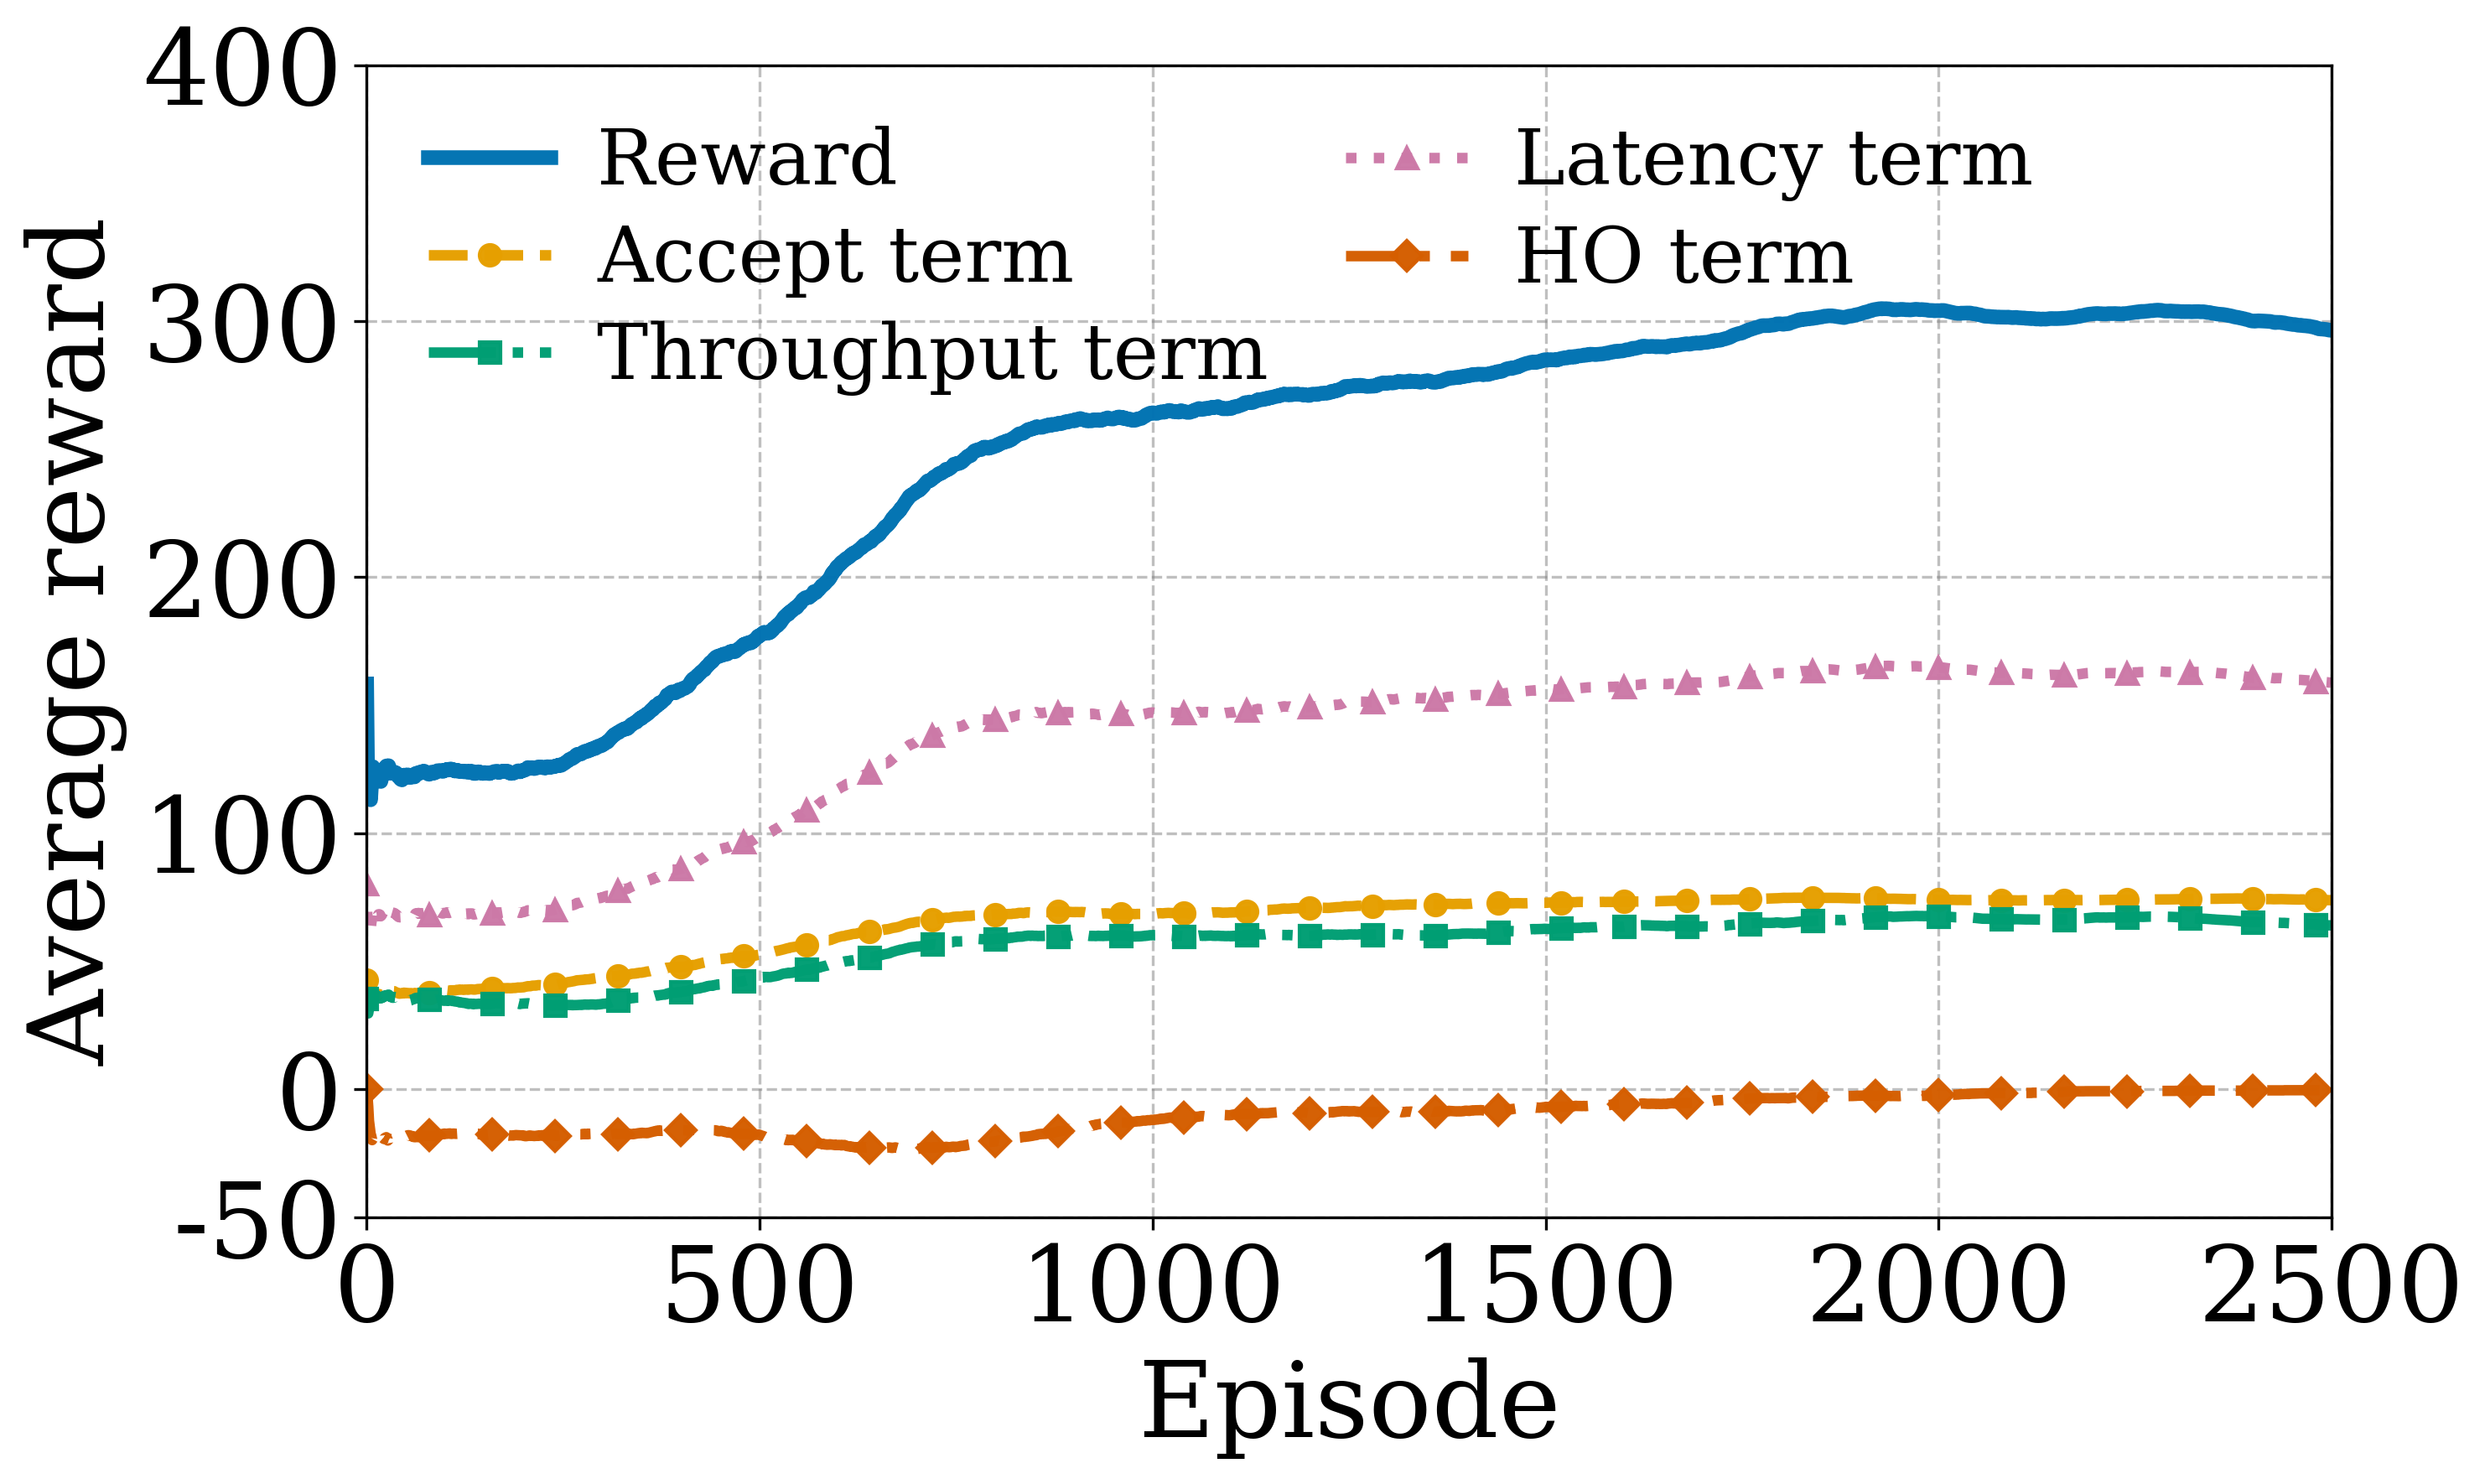

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

COLORS = ['forestgreen', 'darkgoldenrod', 'navy', 'darkviolet', 'red']

def _save(fig, out_dir, fname_base):
    os.makedirs(out_dir, exist_ok=True)
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, f"{fname_base}.pdf"), bbox_inches="tight")
    # plt.close(fig)

# def enable_latex_font():
#     plt.rcParams.update({
#         "text.usetex": True,
#         "axes.unicode_minus": False,
#         "text.latex.preamble": r"""
#             \usepackage{lmodern}
#         """,
#         "font.family": "sans-serif",
#         "axes.labelsize": 30,
#         "axes.titlesize": 30,
#         "xtick.labelsize": 30,
#         "ytick.labelsize": 30,
#         "legend.fontsize": 30,
#     })
def enable_latex_font():
    plt.rcParams.update({
        "text.usetex": False,                                     # Tắt LaTeX hệ thống
        "axes.unicode_minus": False,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"], # Dùng font mặc định giống LaTeX
        "axes.labelsize": 30,
        "axes.titlesize": 30,
        "xtick.labelsize": 30,
        "ytick.labelsize": 30,
        "legend.fontsize": 30,
    })
    
def load_series(results_dir, name):
    path = os.path.join(results_dir, f"{name}.txt")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Không tìm thấy file: {path}")
    data = np.loadtxt(path, dtype=float)
    return np.atleast_1d(data)

def moving_average_full(x, window):
    x = np.asarray(x, dtype=float)
    ma = np.zeros_like(x, dtype=float)

    for i in range(len(x)):
        if i + 1 < window:
            ma[i] = np.mean(x[:i+1])          # chưa đủ window
        else:
            ma[i] = np.mean(x[i-window+1:i+1]) # đủ window

    return ma


def plot_convergence(results_dir):
    enable_latex_font()
    window=200
    reward = load_series(results_dir, "reward")
    acc_term = load_series(results_dir, "acc_term")
    thr_term = load_series(results_dir, "thr_term")
    lat_term = load_series(results_dir, "lat_term")
    ho_term = load_series(results_dir, "handover_term")

    series = [
        ("Reward",         reward,     "#0072B2", "-",  None),
        ("Accept term",    acc_term,   "#E69F00", "--", "o"),
        ("Throughput term", thr_term,  "#009E73", "-.", "s"),
        ("Latency term",   lat_term,   "#CC79A7", ":",  "^"),
        ("HO term",        ho_term,    "#D55E00", (0, (5, 2, 1, 2)), "D"),
    ]

    fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

    for label, data, color, style, marker in series:
        ma = moving_average_full(data, window)
        
        x = np.arange(len(ma))

        lw = 4.2 if label == "Reward" else 3.0
        ms = 6 if marker is not None else 0

        ax.plot(
            x, ma,
            color=color,
            linestyle=style,
            linewidth=lw,
            marker=marker,
            markersize=ms,
            markevery=80,
            label=label,
            alpha=0.98
        )

    ax.set_xlabel("Episode", fontsize=30)
    ax.set_ylabel("Average reward", fontsize=30)
    ax.set_xlim([0, 2500])
    ax.set_ylim([-50, 400])

    # ép tick
    ax.set_yticks([-50, 0, 100, 200, 300, 400])

    ax.grid(which='major', color='gray', linestyle='--', alpha=0.5, zorder=0)
    ax.grid(which='minor', visible=True)

    ax.legend(
        loc="best",
        framealpha=0,
        fontsize=22,
        handlelength=1.6,
        handletextpad=0.6,
        labelspacing=0.3,
        borderpad=0.3,
        ncol=2,
        columnspacing=1.0
    )

    plt.tight_layout()
    _save(fig, results_dir, "convergence")
    plt.show()
    
    

results_dir = "./results/run_PPOGSA_50UE/"
plot_convergence(results_dir)


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

# =========================
# SAVE FUNCTION
# =========================
def _save(fig, out_dir, fname_base):
    os.makedirs(out_dir, exist_ok=True)
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, f"{fname_base}.pdf"), bbox_inches="tight")
    # plt.close(fig)

# =========================
# LATEX FONT
# =========================
# def enable_latex_font():
#     plt.rcParams.update({
#         "text.usetex": True,
#         "axes.unicode_minus": False,
#         "text.latex.preamble": r"\usepackage{lmodern}",
#         "font.family": "sans-serif",
#         "axes.labelsize": 30,
#         "axes.titlesize": 30,
#         "xtick.labelsize": 24,
#         "ytick.labelsize": 24,
#         "legend.fontsize": 20,
#     })
def enable_latex_font():
    plt.rcParams.update({
        "text.usetex": False,
        "axes.unicode_minus": False,
        "mathtext.fontset": "cm",        # ← Dùng bộ font toán học Computer Modern giống LaTeX
        "font.family": "serif",          # ← Chuyển sang font serif cho giống phong cách bài báo
        "axes.labelsize": 30,
        "axes.titlesize": 30,
        "xtick.labelsize": 24,
        "ytick.labelsize": 24,
        "legend.fontsize": 20,
    })

enable_latex_font()

# =========================
# PATH
# =========================
root = Path("./results_evaluation/run_20260413_230901")
out_dir = root / "figures"

methods = ["PPOGSA", "RANDOM", "MAXGAIN", "NO_HANDOVER", "A3_OFFSET"]

def load(p):
    return np.atleast_1d(np.loadtxt(p))

# =========================
# LOAD DATA
# =========================
data = {}

for m in methods:
    base = root / m
    data[m] = {
        "reward": load(base / "evaluation_reward.txt"),
    }

# =========================
# ALIGN LENGTH
# =========================
min_len = min(len(data[m]["reward"]) for m in methods)

for m in methods:
    data[m]["reward"] = data[m]["reward"][:min_len]

episodes = np.arange(min_len)

# =========================
# PLOT
# =========================
fig, ax = plt.subplots(figsize=(10, 6))

for m in methods:
    ax.plot(
        episodes,
        data[m]["reward"],
        label=m,
        linewidth=2,
        marker='o',
        markersize=3
    )

ax.set_xlabel(r"Decision step $t$ (s)")
ax.set_ylabel("Reward")

# crop trục Ox
ax.set_xlim(0, 50)
ax.set_ylim(0, 400)

ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 0.95),
    fontsize=14,   # ↓ nhỏ lại
    frameon=True,
    facecolor="white",
    framealpha=0.95
)
# =========================
# SAVE (NO plt.show())
# =========================
_save(fig, out_dir, "reward_comparison")
plt.show()
plt.close(fig)

FileNotFoundError: results_evaluation/run_20260413_230901/A3_OFFSET/evaluation_reward.txt not found.

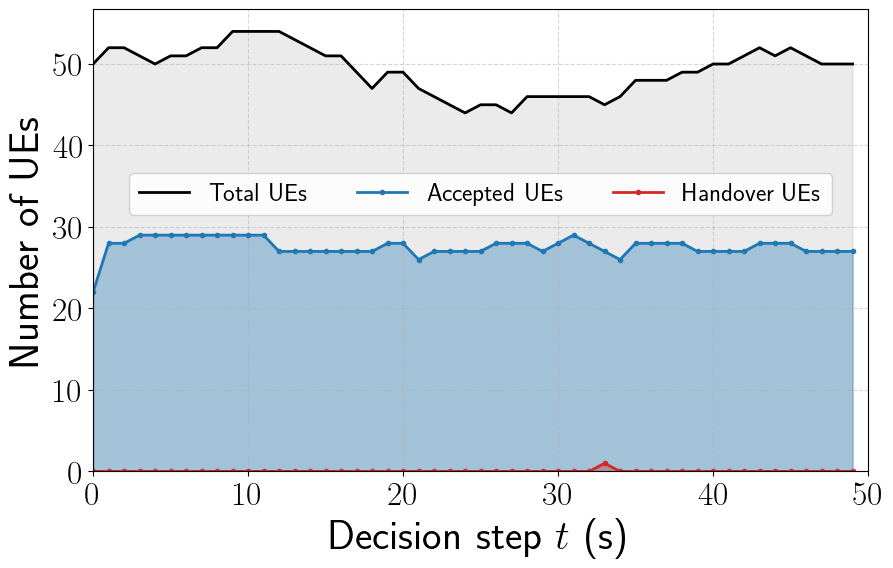

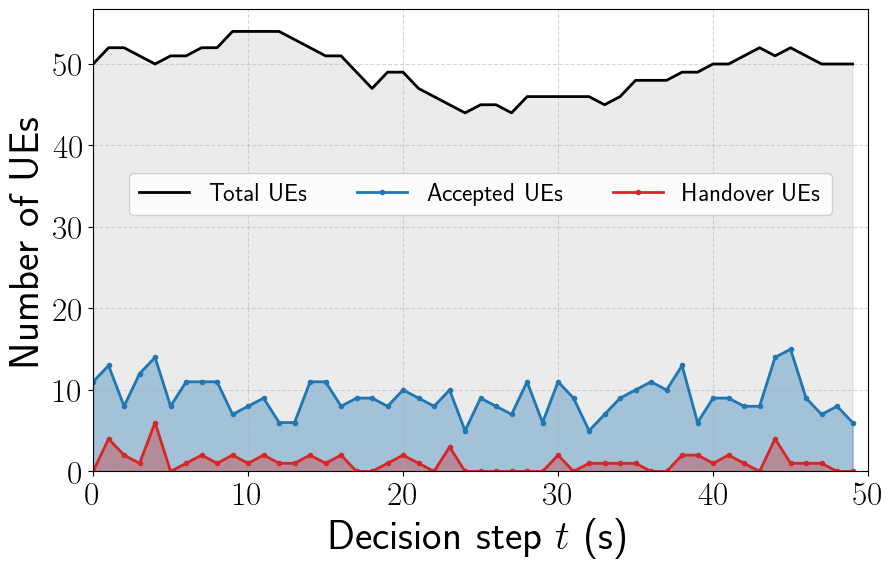

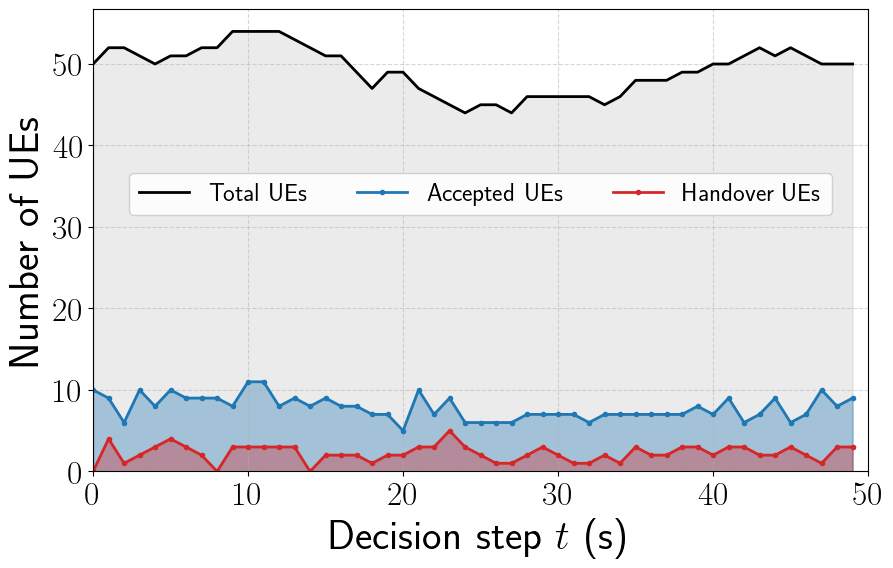

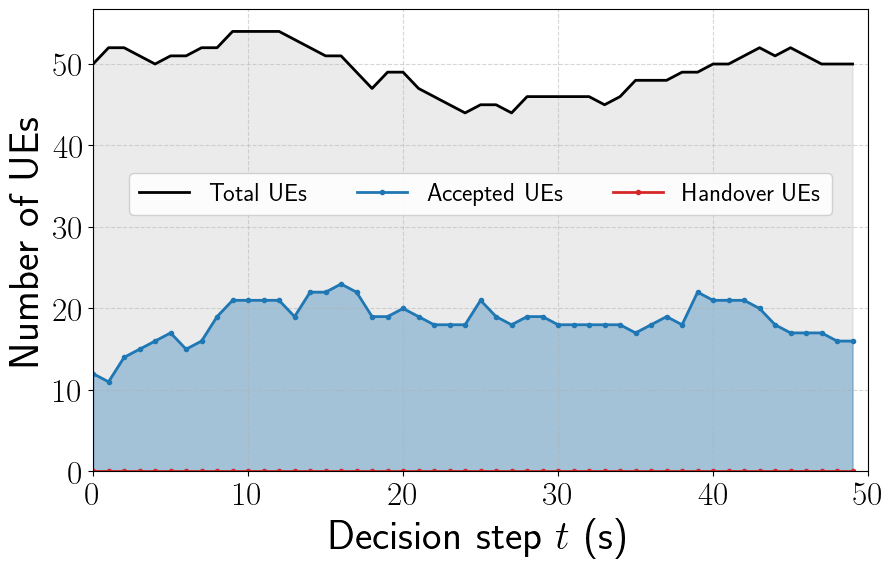

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

# =========================
# SAVE FUNCTION
# =========================
def _save(fig, out_dir, fname_base):
    os.makedirs(out_dir, exist_ok=True)
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, f"{fname_base}.pdf"), bbox_inches="tight")
    plt.close(fig)

# =========================
# LATEX FONT
# =========================
def enable_latex_font():
    plt.rcParams.update({
        "text.usetex": True,
        "axes.unicode_minus": False,
        "text.latex.preamble": r"\usepackage{lmodern}",
        "font.family": "sans-serif",
        "axes.labelsize": 30,
        "axes.titlesize": 30,
        "xtick.labelsize": 24,
        "ytick.labelsize": 24,
        "legend.fontsize": 20,
    })

enable_latex_font()

# =========================
# PATH
# =========================
root = Path("./results_evaluation/run_20260413_230901")
out_dir = root / "figures"

methods = ["PPOGSA", "RANDOM", "MAXGAIN", "NO_HANDOVER"]

def load(p):
    return np.atleast_1d(np.loadtxt(p))

# =========================
# COLOR MAP
# =========================
colors = {
    "total": "black",
    "accept": "tab:blue",
    "handover": "tab:red"
}

# =========================
# MAIN LOOP
# =========================
for method in methods:
    base = root / method

    numUEs = load(base / "evaluation_numUEs.txt")
    accept = load(base / "evaluation_accept.txt")
    handover = load(base / "evaluation_handover.txt")

    min_len = min(len(numUEs), len(accept), len(handover))
    numUEs = numUEs[:min_len]
    accept = accept[:min_len]
    handover = handover[:min_len]

    episodes = np.arange(min_len)

    fig, ax = plt.subplots(figsize=(10, 6))

    # =========================
    # AREA (no label để tránh trùng legend)
    # =========================
    ax.fill_between(
        episodes, 0, numUEs,
        color=colors["total"],
        alpha=0.08
    )

    ax.fill_between(
        episodes, 0, accept,
        color=colors["accept"],
        alpha=0.35
    )

    ax.fill_between(
        episodes, 0, handover,
        color=colors["handover"],
        alpha=0.35
    )

    # =========================
    # LINES (label ở đây)
    # =========================
    line_total, = ax.plot(
        episodes, numUEs,
        color=colors["total"],
        linewidth=2,
        label="Total UEs"
    )

    line_accept, = ax.plot(
        episodes, accept,
        color=colors["accept"],
        linewidth=2,
        marker="o",
        markersize=3,
        label="Accepted UEs"
    )

    line_handover, = ax.plot(
        episodes, handover,
        color=colors["handover"],
        linewidth=2,
        marker="o",
        markersize=3,
        label="Handover UEs"
    )

    # =========================
    # FORMAT
    # =========================

    ax.set_xlabel(r"Decision step $t$ (s)")
    ax.set_ylabel("Number of UEs")

    # set trục
    ax.set_xlim(0, 50)
    ax.set_ylim(bottom=0)

    ax.grid(True, linestyle="--", alpha=0.5)

    # =========================
    # LEGEND (đúng thứ tự)
    # =========================
    ax.legend(
        [line_total, line_accept, line_handover],
        ["Total UEs", "Accepted UEs", "Handover UEs"],
        loc="center",
        bbox_to_anchor=(0.5, 0.6),
        ncol=3,
        fontsize=18,
        frameon=True,
        facecolor="white",
        framealpha=0.9
    )

    plt.show()

    # =========================
    # SAVE
    # =========================
    _save(fig, out_dir, f"{method}_UE_metrics")

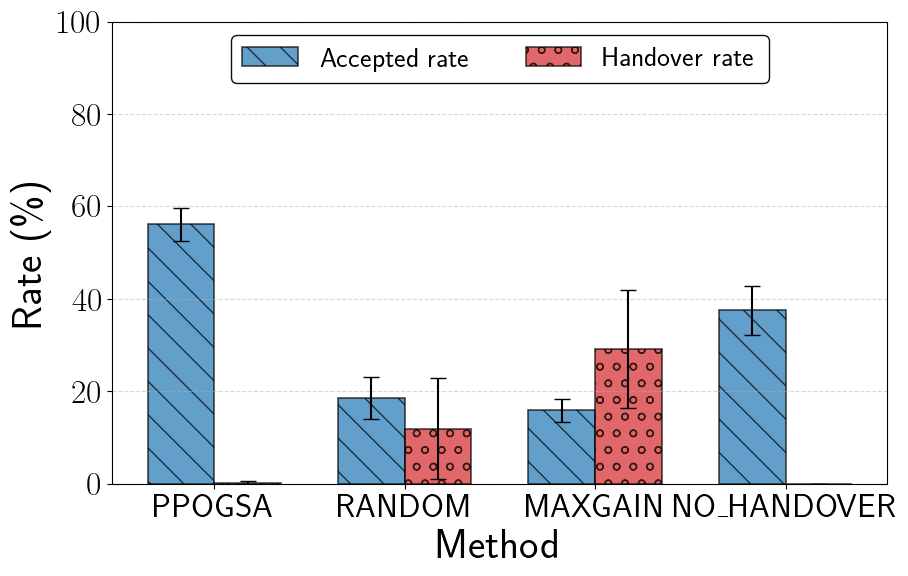

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

# =========================
# STYLE (ĐỒNG BỘ LINE PLOT)
# =========================
COLORS = {
    "accept": "tab:blue",
    "handover": "tab:red"
}

HATCH = {
    "accept": "\\",
    "handover": "o"
}

# =========================
# SAVE FUNCTION
# =========================
def _save(fig, out_dir, fname_base):
    os.makedirs(out_dir, exist_ok=True)
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, f"{fname_base}.pdf"), bbox_inches="tight")
    plt.close(fig)

# =========================
# LATEX FONT
# =========================
def enable_latex_font():
    plt.rcParams.update({
        "text.usetex": True,
        "axes.unicode_minus": False,
        "text.latex.preamble": r"\usepackage{lmodern}",
        "font.family": "sans-serif",
        "axes.labelsize": 30,
        "axes.titlesize": 30,
        "xtick.labelsize": 24,
        "ytick.labelsize": 24,
        "legend.fontsize": 20,
    })

enable_latex_font()

# =========================
# LOAD
# =========================
def load(p):
    return np.atleast_1d(np.loadtxt(p))

# =========================
# PATH
# =========================
root = Path("./results_evaluation/run_20260413_230901")
out_dir = root / "figures"

methods = ["PPOGSA", "RANDOM", "MAXGAIN", "NO_HANDOVER"]

# =========================
# STORE
# =========================
acc_means, acc_stds = [], []
ho_means, ho_stds = [], []

# =========================
# COMPUTE
# =========================
for method in methods:
    base = root / method

    total = load(base / "evaluation_numUEs.txt")
    accept = load(base / "evaluation_accept.txt")
    handover = load(base / "evaluation_handover.txt")

    min_len = min(len(total), len(accept), len(handover))
    total = total[:min_len]
    accept = accept[:min_len]
    handover = handover[:min_len]

    accept_rate = np.divide(
        accept, total,
        out=np.zeros_like(accept, dtype=float),
        where=total > 0
    )

    handover_rate = np.divide(
        handover, accept,
        out=np.zeros_like(handover, dtype=float),
        where=accept > 0
    )

    acc_means.append(np.mean(accept_rate) * 100)
    acc_stds.append(np.std(accept_rate) * 100)

    ho_means.append(np.mean(handover_rate) * 100)
    ho_stds.append(np.std(handover_rate) * 100)

# =========================
# PLOT
# =========================
x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Accepted (dịu hơn)
ax.bar(
    x - width/2,
    acc_means,
    width,
    yerr=acc_stds,
    capsize=6,
    label="Accepted rate",
    color=COLORS["accept"],
    alpha=0.7,              # ↓ làm dịu màu
    edgecolor="black",
    hatch=HATCH["accept"],
    linewidth=1.2
)

# Handover (dịu hơn)
ax.bar(
    x + width/2,
    ho_means,
    width,
    yerr=ho_stds,
    capsize=6,
    label="Handover rate",
    color=COLORS["handover"],
    alpha=0.7,
    edgecolor="black",
    hatch=HATCH["handover"],
    linewidth=1.2
)

# =========================
# FORMAT
# =========================
ax.set_xticks(x)
ax.set_xticklabels(methods)

ax.set_xlabel(r"Method")
ax.set_ylabel("Acceptance rate (\\%)")

ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))

ax.grid(True, axis='y', linestyle="--", alpha=0.5)

# legend gọn, giữa
ax.legend(
    loc="upper center",
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=0.95
)

plt.show()
_save(fig, out_dir, "bar_rate_mean_std_percent")